# load modules

In [1]:
!pip install optuna

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 404.7/404.7 kB 6.0 MB/s eta 0:00:00


In [43]:
from itertools import combinations
import itertools

from sklearn.metrics import silhouette_score, davies_bouldin_score, calinski_harabasz_score

In [3]:
# =========================
# System & File Management
# =========================
import os
import re
import time
import json
import copy
import pickle
from pathlib import Path
import warnings

# =========================
# Data Handling & Numerical
# =========================
import numpy as np
import pandas as pd

# =========================
# Visualization
# =========================
import matplotlib.pyplot as plt
import seaborn as sns
import shap

# =========================
# Statistics
# =========================
from scipy.stats import chi2_contingency, mannwhitneyu

# =========================
# Machine Learning - Preprocessing
# =========================
from sklearn.impute import SimpleImputer
from sklearn.preprocessing import LabelEncoder, OneHotEncoder, StandardScaler
from sklearn.utils import resample
from sklearn.metrics import log_loss

# =========================
# Machine Learning - Modeling & Evaluation
# =========================
from sklearn.cluster import KMeans
from sklearn.ensemble import RandomForestClassifier
from sklearn.neighbors import NearestNeighbors
from sklearn.metrics import (
    accuracy_score,
    average_precision_score,
    classification_report,
    f1_score,
    precision_score,
    recall_score,
    roc_auc_score,
)
from sklearn.model_selection import GroupKFold, StratifiedKFold, train_test_split
from sklearn.metrics import roc_auc_score, average_precision_score, accuracy_score

# =========================
# Optimization
# =========================
import optuna
from optuna.pruners import HyperbandPruner  # or MedianPruner
from optuna.samplers import TPESampler

# =========================
# XGBoost
# =========================
# from xgboost import XGBClassifier
import xgboost as xgb

# =========================
# Deep Learning (PyTorch)
# =========================
import torch
import torch.nn as nn
import torch.nn.functional as F

# =========================
# Dimensionality Reduction & Clustering
# =========================
import umap
import hdbscan

# =========================
# Utilities
# =========================
from tqdm import tqdm
import joblib

# =========================
# Warnings Configuration
# =========================
warnings.filterwarnings("ignore", category=UserWarning)
warnings.filterwarnings("ignore", category=FutureWarning)
warnings.filterwarnings("ignore", category=UserWarning, module='sklearn.impute')
os.environ['PYTHONWARNINGS'] = 'ignore'


/usr/local/lib/python3.12/dist-packages/hdbscan/robust_single_linkage_.py:175: SyntaxWarning: invalid escape sequence '\{'
  $max \{ core_k(a), core_k(b), 1/\alpha d(a,b) \}$.


# Functions

In [4]:
# set the random seed
torch.manual_seed(42)
np.random.seed(42)

In [48]:

##########################
## train a single model ##
##########################

def run_single_train_val(X_train, y_train, X_val, y_val, model_name='xgboost',
                         feature_names=None, tune_params=True,
                        hospital_id=None, random_state=42):

    save_folder = f'saved_models_{model_name}_single'
    os.makedirs(save_folder, exist_ok=True)

    print(f"【{model_name.upper()}】start training - {time.strftime('%Y-%m-%d %H:%M:%S')}")
    model_filename = f'best_{model_name}_{hospital_id}.model' if hospital_id else f'best_{model_name}.model'
    model_path = os.path.join(save_folder, model_filename)
    print(f"✅ model output path: {model_path}")

    dtrain = xgb.DMatrix(X_train, label=y_train)
    dval = xgb.DMatrix(X_val, label=y_val)

    # calculate positve rate
    pos = np.sum(y_train)
    neg = len(y_train) - pos
    scale_pos_weight = neg / pos if pos > 0 else 1.0

    params = {
        'objective': 'binary:logistic',
        'eval_metric': ['logloss', 'aucpr' ],  # monitor AUPRC and logloss
        'learning_rate': 0.01,
        'max_depth': 6,
        'subsample': 0.8,
        'colsample_bytree': 0.8,
        'seed': random_state,
        'nthread': 1,
        'verbosity': 0,
        'scale_pos_weight': scale_pos_weight
    }

    if tune_params:
        best_score = float('inf')  # logloss
        best_params = params.copy()
        for depth, lr in itertools.product([2,4, 6, 8,10], [0.001, 0.01, 0.05, 0.1]):
            tmp_params = params.copy()
            tmp_params.update({'max_depth': depth, 'learning_rate': lr})
            bst_tmp = xgb.train(
                tmp_params,
                dtrain,
                num_boost_round=1000,
                evals=[(dval, 'eval')],
                verbose_eval=False
            )
            preds = bst_tmp.predict(dval)
            score = log_loss(y_val, preds)
            if score < best_score:
                best_score = score
                best_params.update({'max_depth': depth, 'learning_rate': lr})
        params = best_params
        print(f"🔧 done parameter selection | best max_depth={params['max_depth']}, learning_rate={params['learning_rate']}")

    print(f"\n🏗️ training {model_name}...")
    start_time = time.time()

    bst = xgb.train(
        params=params,
        dtrain=dtrain,
        num_boost_round=1000,
        evals=[(dtrain, 'train'), (dval, 'eval')],
        early_stopping_rounds=30,
        verbose_eval=20,
        maximize=False
    )

    train_time = time.time() - start_time
    print(f"✅ completed training | time taken: {train_time:.1f}s")

    print("\n📊 model evaluation...")
    val_preds = bst.predict(dval)

    auroc = roc_auc_score(y_val, val_preds)
    auprc = average_precision_score(y_val, val_preds)
    accuracy = accuracy_score(y_val, val_preds > 0.5)

    # Bootstrap evaluation
    n_bootstrap = 1000
    auroc_samples = []
    auprc_samples = []

    for _ in tqdm(range(n_bootstrap), desc="Bootstrap evaluation"):
        idx = resample(np.arange(len(y_val)), stratify=y_val)
        auroc_samples.append(roc_auc_score(y_val[idx], val_preds[idx]))
        auprc_samples.append(average_precision_score(y_val[idx], val_preds[idx]))

    auroc_ci = np.percentile(auroc_samples, [2.5, 97.5])
    auprc_ci = np.percentile(auprc_samples, [2.5, 97.5])

    # save the model
    bst.save_model(model_path)

    # extract the feature importance
    feature_importances = {}
    if feature_names is not None:
        fmap = {f'f{i}': name for i, name in enumerate(feature_names)}
        score = bst.get_score(importance_type='weight')
        for k, v in score.items():
            feature_importances[fmap.get(k, k)] = v

    eval_results = {
        'metrics': {
            'auroc': auroc,
            'auroc_ci': list(auroc_ci),
            'auprc': auprc,
            'auprc_ci': list(auprc_ci),
            'accuracy': accuracy,
            'train_time_s': train_time
        },
        'model_path': model_path,
        'feature_importances': feature_importances
    }

    print("\n🎯 final output:")
    print(f"AUROC: {auroc:.4f} (95% CI: {auroc_ci[0]:.4f} - {auroc_ci[1]:.4f})")
    print(f"AUPRC: {auprc:.4f} (95% CI: {auprc_ci[0]:.4f} - {auprc_ci[1]:.4f})")
    print(f"Accuracy: {accuracy:.4f}")

    # ============ 🔁 retrain on full train+val ==============
    print("\n🔁 combine train + val for final training...")
    dfull = xgb.DMatrix(np.concatenate([X_train, X_val]), label=np.concatenate([y_train, y_val]))

    bst_final = xgb.train(
        params=params,
        dtrain=dfull,
        num_boost_round=bst.best_iteration + 1
    )

    final_model_path = model_path.replace('.model', '_final.model')
    bst_final.save_model(final_model_path)

    print(f"✅ trained model saved to: {final_model_path}")
    eval_results['final_model_path'] = final_model_path

    return eval_results

##########################
## identify the cluster ##
##########################

def run_shap_umap_hdbscan_analysis(k_neighbors, model_path, hospital_id):

    # Create base output directory (hospital-specific)
    base_folder = f'/content/cluster_{hospital_id}'
    os.makedirs(base_folder, exist_ok=True)

    # Create subdirectory for the current experiment setting
    save_folder = os.path.join(base_folder, f'{hospital_id}_{k_neighbors}')
    os.makedirs(save_folder, exist_ok=True)

    # Load trained XGBoost booster
    booster = xgb.Booster()
    booster.load_model(model_path)

    # # Wrap booster with sklearn-compatible XGBClassifier
    model = xgb.XGBClassifier()
    model._Booster = booster

    # Run SHAP + HDBSCAN + UMAP analysis
    generate_shap_hdbscan_umap_analysis(
        model,
        X_target_train,
        y_target_train,
        X_target_test,
        y_target_test,
        save_folder=save_folder,
        k_neighbors=7
    )

def generate_shap_hdbscan_umap_analysis(model, X_train, y_train, X_val, y_val,
                                        save_folder='./results',
                                        k_neighbors=5):
    os.makedirs(save_folder, exist_ok=True)

    # if feature_names is None:
    #     feature_names = [f'feature_{i}' for i in range(X_train.shape[1])]

    # make sure y is pd.Series
    if isinstance(y_train, np.ndarray):
        y_train = pd.Series(y_train, index=X_train.index)
    if isinstance(y_val, np.ndarray):
        y_val = pd.Series(y_val, index=X_val.index)

    print("calcualte training set SHAP values...")
    explainer = shap.TreeExplainer(model)
    shap_values_train = explainer.shap_values(X_train)
    if isinstance(shap_values_train, list):
        shap_values_train = shap_values_train[1]
    if len(shap_values_train.shape) == 3:
        shap_values_train = shap_values_train[:, :, 1]

    print("training HDBSCAN clustering...")
    clusterer = hdbscan.HDBSCAN(min_cluster_size=75, min_samples= 100)
    cluster_labels_train = clusterer.fit_predict(shap_values_train)

    # clustering metrics quality evaluation, excluded cluster -1
    mask = cluster_labels_train != -1
    if np.sum(mask) > 1:
        sil = silhouette_score(shap_values_train[mask], cluster_labels_train[mask])
        db = davies_bouldin_score(shap_values_train[mask], cluster_labels_train[mask])
        ch = calinski_harabasz_score(shap_values_train[mask], cluster_labels_train[mask])
        print(f"Internal clustering metrics (non-noise samples)：Silhouette: {sil:.3f}, DB: {db:.3f}, CH: {ch:.3f}")
    else:
        print("Too many noise points in clustering result; internal metrics are not computed")

    # Fit a KNN model on training-set SHAP representations
    nn = NearestNeighbors(n_neighbors=k_neighbors).fit(shap_values_train)


    print("Computing SHAP values for validation set and mapping clusters...")
    shap_values_val = explainer.shap_values(X_val)
    if isinstance(shap_values_val, list):
        shap_values_val = shap_values_val[1]
    if len(shap_values_val.shape) == 3:
        shap_values_val = shap_values_val[:, :, 1]

    _, indices = nn.kneighbors(shap_values_val)
    neighbor_labels = cluster_labels_train[indices]  # shape: (n_val_samples, k)

    def majority_vote(labels_row):
        labels, counts = np.unique(labels_row, return_counts=True)
        if len(labels) == 0:
            return -1
        if (labels == -1).any() and counts[labels == -1][0] > k_neighbors // 2:
            return -1
        non_noise = [(l, c) for l, c in zip(labels, counts) if l != -1]
        if len(non_noise) == 0:
            return -1
        return max(non_noise, key=lambda x: x[1])[0]

    cluster_labels_val = np.apply_along_axis(majority_vote, axis=1, arr=neighbor_labels)

    # UMAP dimensionality reduction for visualization only
    # print("Performing UMAP visualization of clustering results...")
    # reducer = umap.UMAP(n_components=2, n_neighbors=15, min_dist=0.1, random_state=42)
    # embedding_train = reducer.fit_transform(shap_values_train)
    # embedding_val = reducer.transform(shap_values_val)

    # Fit UMAP on training-set SHAP values and project them to 2D
    # plot_and_metrics(embedding_train, cluster_labels_train, y_train, X_train, X_train.index, model, save_folder, prefix='train')
    # plot_and_metrics(embedding_val, cluster_labels_val, y_val, X_val, X_val.index, model, save_folder, prefix='val')

    # Combine training and validation sample indices and cluster labels
    sample_clusters_combined = pd.DataFrame({
        'sample_index': pd.concat([X_train.index.to_series(), X_val.index.to_series()]),
        'set': ['train'] * len(X_train) + ['val'] * len(X_val),
        'cluster_id': np.concatenate([cluster_labels_train, cluster_labels_val])
    })
    sample_clusters_combined.to_csv(os.path.join(save_folder, 'sample_cluster_assignments_combined.csv'), index=False)

    print("✅ SHAP + HDBSCAN completed. Results saved to:", save_folder)

#############################################
## evaluate cluster wise model performance ##
#############################################

def evaluate_all_cluster_combinations(
    cluster_csv_path,
    X_target_test,
    y_target_test,
    model_path,
    clusters_to_include,
    min_comb_size=1,
    max_comb_size=2,
    n_bootstrap=1000,
    output_dir='./results',
    random_seed=42
):
    os.makedirs(output_dir, exist_ok=True)
    all_combs = []
    for k in range(min_comb_size, max_comb_size + 1):
        all_combs.extend(list(combinations(clusters_to_include, k)))

    results_summary = []
    skipped_records = []

    for comb in tqdm(all_combs):
        comb_name = "_".join(map(str, comb))
        output_csv = f"cluster_{comb_name}_results.csv"
        try:
            result = evaluate_model_with_bootstrap(
                cluster_csv_path=cluster_csv_path,
                X_target_test=X_target_test.copy(),
                y_target_test=y_target_test.copy(),
                model_path=model_path,
                clusters_to_include=list(comb),
                n_bootstrap=n_bootstrap,
                output_dir=output_dir,
                output_csv_name=output_csv,
                random_seed=random_seed
            )
            if result is not None:
                results_summary.append({
                    "combination": comb_name,
                    "num_samples": result["num_samples"],
                    "positive_rate": result["positive_rate"],

                    "auc": result["auc"],
                    "auc_ci_lower": result["auc_ci"][0],
                    "auc_ci_upper": result["auc_ci"][1],
                    "auc_pval": result["auc_pval"],

                    "auprc": result["auprc"],
                    "auprc_ci_lower": result["auprc_ci"][0],
                    "auprc_ci_upper": result["auprc_ci"][1],
                    "auprc_pval": result["auprc_pval"],

                    "logloss": result["logloss"],
                    "logloss_ci_lower": result["logloss_ci"][0],
                    "logloss_ci_upper": result["logloss_ci"][1],
                    "logloss_pval": result["logloss_pval"]
                })

        except Exception as e:
            print(f"❌ cluster {comb_name} raise error: {e}")
            skipped_records.append({"combination": comb_name, "error": str(e)})

    summary_df = pd.DataFrame(results_summary)
    summary_path = os.path.join(output_dir, "summary_results.csv")
    summary_df.to_csv(summary_path, index=False)

    skipped_path = os.path.join(output_dir, "skipped_combinations.csv")
    pd.DataFrame(skipped_records).to_csv(skipped_path, index=False)
    print(f"✅ done and saved to {output_dir}")

def evaluate_model_with_bootstrap(
    cluster_csv_path,
    X_target_test,
    y_target_test,
    model_path,
    clusters_to_include=[1, 2, 3],
    n_bootstrap=1000,
    output_dir='/content/boots_output',
    output_csv_name='all-test-1.csv',
    random_seed=42
):
    df_2 = pd.read_csv(cluster_csv_path)
    index_to_cluster = df_2.set_index("sample_index")["cluster_id"]
    X_target_test["cluster_id"] = X_target_test.index.map(index_to_cluster)
    null_count = X_target_test['cluster_id'].isnull().sum()
    print(f"missing cluster_id size: {null_count}")

    mask = X_target_test['cluster_id'].isin(clusters_to_include)
    X_target_test_sub = X_target_test[mask]
    y_target_test_sub = y_target_test[mask.values]
    num_samples = len(X_target_test_sub)
    pos_rate = y_target_test_sub.mean() * 100
    print(f" Cluser  {clusters_to_include}：sample size {num_samples}, Positive Rate: {pos_rate:.2f}%")

    if len(np.unique(y_target_test_sub)) < 2:
        label_val = y_target_test_sub[0]
        print(f"⚠️ this cluster only include one lable (label={label_val}), skip evalution")
        return None

    X_target_test_sub = X_target_test_sub.drop(columns=['cluster_id'])

    model = xgb.Booster()
    model.load_model(model_path)
    dtest = xgb.DMatrix(X_target_test_sub)
    test_preds_proba = model.predict(dtest)

    test_auc = roc_auc_score(y_target_test_sub, test_preds_proba)
    test_auprc = average_precision_score(y_target_test_sub, test_preds_proba)
    test_logloss = log_loss(y_target_test_sub, test_preds_proba)

    print(f"🎯 test set AUC: {test_auc:.4f}")
    print(f"🎯 test set AUPRC: {test_auprc:.4f}")
    print(f"🎯 test set LogLoss: {test_logloss:.4f}")

    rng = np.random.default_rng(seed=random_seed)
    aucs, auprcs, loglosses = [], [], []
    for _ in range(n_bootstrap):
        indices = rng.choice(len(y_target_test_sub), size=len(y_target_test_sub), replace=True)
        y_true_boot = y_target_test_sub[indices]
        y_pred_boot = test_preds_proba[indices]
        if len(np.unique(y_true_boot)) < 2:
            continue
        aucs.append(roc_auc_score(y_true_boot, y_pred_boot))
        auprcs.append(average_precision_score(y_true_boot, y_pred_boot))
        loglosses.append(log_loss(y_true_boot, y_pred_boot))

    auc_ci = np.percentile(aucs, [2.5, 97.5])
    auprc_ci = np.percentile(auprcs, [2.5, 97.5])
    logloss_ci = np.percentile(loglosses, [2.5, 97.5])

    # ================== p-value calculation ==================
    baseline_auc = 0.5
    baseline_auprc = y_target_test_sub.mean()
    baseline_logloss = log_loss(
        y_target_test_sub,
        np.full_like(y_target_test_sub, baseline_auprc, dtype=float)
    )

    pval_auc = np.mean(np.array(aucs) <= baseline_auc)
    pval_auprc = np.mean(np.array(auprcs) <= baseline_auprc)
    pval_logloss = np.mean(np.array(loglosses) >= baseline_logloss)


    print(f"✅ test set AUC: {test_auc:.4f} (95% CI: {auc_ci[0]:.4f} - {auc_ci[1]:.4f})")
    print(f"✅ test set AUPRC: {test_auprc:.4f} (95% CI: {auprc_ci[0]:.4f} - {auprc_ci[1]:.4f})")
    print(f"✅ test set LogLoss: {test_logloss:.4f} (95% CI: {logloss_ci[0]:.4f} - {logloss_ci[1]:.4f})")

    os.makedirs(output_dir, exist_ok=True)

    # save bootstrap output
    bootstrap_df = pd.DataFrame({'auc': aucs, 'auprc': auprcs, 'logloss': loglosses})
    csv_path = os.path.join(output_dir, output_csv_name)
    bootstrap_df.to_csv(csv_path, index=False)

    # # skipped
    # bootstrap_df_long = bootstrap_df.melt(var_name='Metric', value_name='Score')
    # plt.figure(figsize=(8, 6))
    # sns.boxplot(data=bootstrap_df_long, x='Metric', y='Score', palette='Set2')
    # plt.title(f'Bootstrap Metrics (n={num_samples}, pos={pos_rate:.1f}%)')
    # plt.tight_layout()
    # png_path = csv_path.replace('.csv', '.png')
    # plt.savefig(png_path)
    # plt.close()

    # SHAP values
    explainer = shap.TreeExplainer(model)
    shap_values = explainer.shap_values(X_target_test_sub)
    shap_df = pd.DataFrame(shap_values, columns=X_target_test_sub.columns, index=X_target_test_sub.index)
    shap_csv_path = csv_path.replace('.csv', '_shap.csv')
    shap_df.to_csv(shap_csv_path)

    shap.summary_plot(shap_values, X_target_test_sub, show=False)
    shap_png_path = csv_path.replace('.csv', '_shap.png')
    plt.savefig(shap_png_path)
    plt.close()

    return {
        "auc": test_auc, "auc_ci": auc_ci, "auc_pval": pval_auc,
        "auprc": test_auprc, "auprc_ci": auprc_ci, "auprc_pval": pval_auprc,
        "logloss": test_logloss, "logloss_ci": logloss_ci, "logloss_pval": pval_logloss,
        "bootstrap_df": bootstrap_df,
        "num_samples": num_samples,
        "positive_rate": pos_rate
    }

def retrain_and_evaluate_all_cluster_combinations(
    cluster_csv_path,
    X_train, y_train,
    X_test, y_test,
    clusters_to_include,
    min_comb_size=1,
    max_comb_size=2,
    n_bootstrap=1000,
    output_dir="./cluster_retrain_results",
    random_seed=42
):
    os.makedirs(output_dir, exist_ok=True)

    # ================== 1️⃣ readin CSV  ==================
    cluster_df = pd.read_csv(cluster_csv_path)
    cluster_df = cluster_df.rename(columns={
        "sample_index": "sample_id",
        "cluster_id": "cluster"
    })
    cluster_df["sample_id"] = cluster_df["sample_id"].astype(str)

    # indexing
    X_train.index = X_train.index.astype(str)
    X_test.index = X_test.index.astype(str)
    y_train.index = y_train.index.astype(str)
    y_test.index = y_test.index.astype(str)

    # ================== 2️⃣  cluster combinations ==================
    all_combs = []
    for k in range(min_comb_size, max_comb_size + 1):
        all_combs.extend(list(combinations(clusters_to_include, k)))

    results_summary = []
    skipped_records = []

    for comb in tqdm(all_combs, desc="Cluster combinations"):
        comb_name = "_".join(map(str, comb))
        print(f"\n🚀 Cluster reyraining: {comb_name}")

        try:
            # ================== 3️⃣  cluster & set for train / val(test) selection ==================
            X_tr, y_tr = filter_data_by_clusters(
                X_train, y_train,
                cluster_df[cluster_df["set"]=="train"],
                comb
            )
            X_te, y_te = filter_data_by_clusters(
                X_test, y_test,
                cluster_df[cluster_df["set"]=="val"],
                comb
            )

            # QC：sample size & positive sample size
            if len(y_tr) < 500:
                raise ValueError("sample size too small")
            if y_tr.sum() == 0 or y_te.sum() == 0:
                raise ValueError("No positive case")

            # ================== 4️⃣ train / internal val split ==================
            X_subtr, X_val, y_subtr, y_val = train_test_split(
                X_tr, y_tr,
                test_size=0.2,
                stratify=y_tr,
                random_state=random_seed
            )

            # ================== 5️⃣ retrain the model ==================
            eval_results = run_single_train_val(
                X_train=X_subtr,
                y_train=y_subtr,
                X_val=X_val,
                y_val=y_val,
                feature_names=X_tr.columns.tolist(),
                hospital_id=f"19_cluster_{comb_name}",
                random_state=random_seed,
                tune_params= True
            )

            # ================== 6️⃣ train set bootstrap evaluation ==================
            val_result = evaluate_model_on_test_set_with_shap(
                X_test=X_tr,
                y_test=y_tr,
                model_path=eval_results["final_model_path"],
                n_bootstrap=1000,
                output_dir="./cluster_retrain_results-val",
                output_csv_name=f"cluster_{comb_name}.csv"
            )

            # ================== 6️⃣ test set bootstrap evaluation ==================
            test_result = evaluate_model_on_test_set_with_shap(
                X_test=X_te,
                y_test=y_te,
                model_path=eval_results["final_model_path"],
                n_bootstrap=1000,
                output_dir="./cluster_retrain_results",
                output_csv_name=f"cluster_{comb_name}_test.csv"
            )

            # ================== 7️⃣ save the output ==================
            results_summary.append({
                "combination": comb_name,

                # ===== sample information =====
                "num_train": len(y_tr),
                "num_val": len(y_val),
                "num_test": len(y_te),

                "positive_rate_train": y_tr.mean(),
                "positive_rate_val": y_val.mean(),
                "positive_rate_test": y_te.mean(),

                # ===== Internal val (bootstrap on sub-train) =====
                "val_auc": val_result["auc"],
                "val_auc_ci_lower": val_result["auc_ci"][0],
                "val_auc_ci_upper": val_result["auc_ci"][1],
                "val_auc_pval": val_result["auc_pval"],

                "val_auprc": val_result["auprc"],
                "val_auprc_ci_lower": val_result["auprc_ci"][0],
                "val_auprc_ci_upper": val_result["auprc_ci"][1],
                "val_auprc_pval": val_result["auprc_pval"],

                "val_logloss": val_result["logloss"],
                "val_logloss_ci_lower": val_result["logloss_ci"][0],
                "val_logloss_ci_upper": val_result["logloss_ci"][1],
                "val_logloss_pval": val_result["logloss_pval"],

                # ===== External test =====
                "test_auc": test_result["auc"],
                "test_auc_ci_lower": test_result["auc_ci"][0],
                "test_auc_ci_upper": test_result["auc_ci"][1],
                "test_auc_pval": test_result["auc_pval"],

                "test_auprc": test_result["auprc"],
                "test_auprc_ci_lower": test_result["auprc_ci"][0],
                "test_auprc_ci_upper": test_result["auprc_ci"][1],
                "test_auprc_pval": test_result["auprc_pval"],

                "test_logloss": test_result["logloss"],
                "test_logloss_ci_lower": test_result["logloss_ci"][0],
                "test_logloss_ci_upper": test_result["logloss_ci"][1],
                "test_logloss_pval": test_result["logloss_pval"],
            })


        except Exception as e:
            print(f"❌ Cluster {comb_name} failed: {e}")
            skipped_records.append({
                "combination": comb_name,
                "error": str(e)
            })

    # ================== 8️⃣ save and export the output ==================
    pd.DataFrame(results_summary).to_csv(
        os.path.join(output_dir, "summary_cluster_retrained_models.csv"),
        index=False
    )
    pd.DataFrame(skipped_records).to_csv(
        os.path.join(output_dir, "skipped_cluster_retrained_models.csv"),
        index=False
    )

    print(f"\n✅  cluster retrained completed {output_dir}")


def evaluate_model_on_test_set_with_shap(
    X_test,
    y_test,
    model_path,
    n_bootstrap=1000,
    output_dir='./boots_output',
    output_csv_name='test_results.csv',
    random_seed=42
):
    os.makedirs(output_dir, exist_ok=True)

    # ------------------- 1️⃣ load the model -------------------
    model = xgb.Booster()
    model.load_model(model_path)
    dtest = xgb.DMatrix(X_test)
    test_preds_proba = model.predict(dtest)

    # ------------------- 2️⃣ calculate the metrics -------------------
    test_auc = roc_auc_score(y_test, test_preds_proba)
    test_auprc = average_precision_score(y_test, test_preds_proba)
    test_logloss = log_loss(y_test, test_preds_proba)

    # ------------------- 3️⃣ Bootstrap -------------------
    rng = np.random.default_rng(seed=random_seed)
    aucs, auprcs, loglosses = [], [], []

    for _ in range(n_bootstrap):
        indices = rng.choice(len(y_test), size=len(y_test), replace=True)
        y_true_boot = y_test.iloc[indices] if isinstance(y_test, pd.Series) else y_test[indices]
        y_pred_boot = test_preds_proba[indices]
        if len(np.unique(y_true_boot)) < 2:
            continue
        aucs.append(roc_auc_score(y_true_boot, y_pred_boot))
        auprcs.append(average_precision_score(y_true_boot, y_pred_boot))
        loglosses.append(log_loss(y_true_boot, y_pred_boot))

    aucs = np.array(aucs)
    auprcs = np.array(auprcs)
    loglosses = np.array(loglosses)

    auc_ci = np.percentile(aucs, [2.5, 97.5])
    auprc_ci = np.percentile(auprcs, [2.5, 97.5])
    logloss_ci = np.percentile(loglosses, [2.5, 97.5])

    # ------------------- 3️⃣ p-value calculation -------------------
    # baseline
    baseline_auc = 0.5
    baseline_auprc = y_test.mean()  # random guess AUPRC
    baseline_logloss = log_loss(y_test, np.full_like(y_test, baseline_auprc))

    pval_auc = np.mean(aucs <= baseline_auc)
    pval_auprc = np.mean(auprcs <= baseline_auprc)
    pval_logloss = np.mean(loglosses >= baseline_logloss)  # lower is better

    print(f"AUC: {test_auc:.4f} (95% CI: {auc_ci[0]:.4f}-{auc_ci[1]:.4f}), p={pval_auc:.4f}")
    print(f"AUPRC: {test_auprc:.4f} (95% CI: {auprc_ci[0]:.4f}-{auprc_ci[1]:.4f}), p={pval_auprc:.4f}")
    print(f"LogLoss: {test_logloss:.4f} (95% CI: {logloss_ci[0]:.4f}-{logloss_ci[1]:.4f}), p={pval_logloss:.4f}")

    # ------------------- 4️⃣ save bootstrap data & figure -------------------
    bootstrap_df = pd.DataFrame({'auc': aucs, 'auprc': auprcs, 'logloss': loglosses})
    csv_path = os.path.join(output_dir, output_csv_name)
    bootstrap_df.to_csv(csv_path, index=False)

    # # plot the box plot (which is not utlized in publication)
    # bootstrap_df_long = bootstrap_df.melt(var_name='Metric', value_name='Score')
    # plt.figure(figsize=(8,6))
    # sns.boxplot(data=bootstrap_df_long, x='Metric', y='Score', palette='Set2')
    # plt.title(f'Bootstrap Metrics (n={len(y_test)})')
    # plt.tight_layout()
    # plt.savefig(csv_path.replace('.csv', '.png'))
    # plt.close()

    # ------------------- 5️⃣ SHAP analysis -------------------
    explainer = shap.TreeExplainer(model)
    shap_values = explainer.shap_values(X_test)

    shap_df = pd.DataFrame(shap_values, columns=X_test.columns, index=X_test.index)
    shap_csv_path = csv_path.replace('.csv', '_shap.csv')
    shap_df.to_csv(shap_csv_path)

    shap.summary_plot(shap_values, X_test, show=False)
    shap_png_path = csv_path.replace('.csv', '_shap.png')
    plt.savefig(shap_png_path)
    plt.close()

    # ------------------- 6️⃣ return the results -------------------
    return {
        "auc": test_auc, "auc_ci": auc_ci, "auc_pval": pval_auc,
        "auprc": test_auprc, "auprc_ci": auprc_ci, "auprc_pval": pval_auprc,
        "logloss": test_logloss, "logloss_ci": logloss_ci, "logloss_pval": pval_logloss,
        "bootstrap_df": bootstrap_df,
        "shap_values": shap_df
    }

def filter_data_by_clusters(X, y, cluster_df, clusters_to_include):
    keep_ids = cluster_df.loc[
        cluster_df["cluster"].isin(clusters_to_include),
        "sample_id"
    ]
    print(f"combination {clusters_to_include} original keep_ids size: {len(keep_ids)}")

    keep_ids = pd.Index(keep_ids).intersection(X.index)
    print(f" X.index shared sie: {len(keep_ids)}")

    X_sub = X.loc[keep_ids].copy()
    y_sub = y.loc[keep_ids].copy()
    return X_sub, y_sub

# data load and preprocession

In [6]:
df = pd.read_csv('/content/training_v2.csv')

In [ ]:
df.head(2)

,encounter_id,patient_id,hospital_id,hospital_death,age,bmi,elective_surgery,ethnicity,gender,height,...,aids,cirrhosis,diabetes_mellitus,hepatic_failure,immunosuppression,leukemia,lymphoma,solid_tumor_with_metastasis,apache_3j_bodysystem,apache_2_bodysystem
0,66154,25312,118,0,68.0,22.73,0,Caucasian,M,180.3,...,0.0,0.0,1.0,0.0,0.0,0.0,0.0,0.0,Sepsis,Cardiovascular
1,114252,59342,81,0,77.0,27.42,0,Caucasian,F,160.0,...,0.0,0.0,1.0,0.0,0.0,0.0,0.0,0.0,Respiratory,Respiratory


In [7]:
df_top20 = df[df['hospital_id'] == 19] # done

In [8]:
len(df_top20)

3925

In [9]:
df_top20.head(2)

,encounter_id,patient_id,hospital_id,hospital_death,age,bmi,elective_surgery,ethnicity,gender,height,...,aids,cirrhosis,diabetes_mellitus,hepatic_failure,immunosuppression,leukemia,lymphoma,solid_tumor_with_metastasis,apache_3j_bodysystem,apache_2_bodysystem
61541,89333,4741,19,1,78.0,27.439446,0,Caucasian,F,170.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,Neurological,Neurologic
61542,4100,38217,19,0,55.0,19.140625,0,Caucasian,F,160.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,Respiratory,Respiratory


In [10]:
df_top1 = df_top20.copy()

In [11]:
mask = df_top1['gcs_unable_apache'] == 1

df_top1.loc[mask, ['gcs_eyes_apache', 'gcs_motor_apache', 'gcs_verbal_apache']] = 0

In [12]:
df_top1['readmission_status'].value_counts()

,count
readmission_status,
0,3925


In [13]:
df_top1.head(2)

,encounter_id,patient_id,hospital_id,hospital_death,age,bmi,elective_surgery,ethnicity,gender,height,...,aids,cirrhosis,diabetes_mellitus,hepatic_failure,immunosuppression,leukemia,lymphoma,solid_tumor_with_metastasis,apache_3j_bodysystem,apache_2_bodysystem
61541,89333,4741,19,1,78.0,27.439446,0,Caucasian,F,170.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,Neurological,Neurologic
61542,4100,38217,19,0,55.0,19.140625,0,Caucasian,F,160.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,Respiratory,Respiratory


In [15]:
df_top1.head(2)

,encounter_id,patient_id,hospital_id,hospital_death,age,bmi,elective_surgery,ethnicity,gender,height,...,aids,cirrhosis,diabetes_mellitus,hepatic_failure,immunosuppression,leukemia,lymphoma,solid_tumor_with_metastasis,apache_3j_bodysystem,apache_2_bodysystem
61541,89333,4741,19,1,78.0,27.439446,0,Caucasian,F,170.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,Neurological,Neurologic
61542,4100,38217,19,0,55.0,19.140625,0,Caucasian,F,160.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,Respiratory,Respiratory


In [16]:
cols_to_drop = [
    # 'hospital_death',
    'apache_4a_hospital_death_prob',
    'apache_4a_icu_death_prob',
    'encounter_id',
    'patient_id',
    'icu_id'
]

df_top1 = df_top1.drop(columns=cols_to_drop)

In [ ]:
len(df_top1)

3925

# Fedattention

In [20]:
df_top1 = df_top1.dropna(subset=['hospital_death'])

In [21]:
df_top1['hospital_id'].value_counts()

,count
hospital_id,
19,3925


In [22]:
df_top1.groupby('hospital_id')['hospital_death'].value_counts()


hospital_id  hospital_death
19           0                 3531
             1                  394
Name: count, dtype: int64

In [23]:
# feature exclusion by missings
threshold = 0.1  # 10%
missing_pct = df_top1.drop(columns=['hospital_death']).isna().mean()
cols_to_drop = missing_pct[missing_pct > threshold].index.tolist()
df_top1.drop(columns=cols_to_drop, inplace=True)
print("Dropped columns (missing > 10%):", cols_to_drop)

Dropped columns (missing > 10%): ['hospital_admit_source', 'albumin_apache', 'bilirubin_apache', 'bun_apache', 'creatinine_apache', 'fio2_apache', 'glucose_apache', 'hematocrit_apache', 'paco2_apache', 'paco2_for_ph_apache', 'pao2_apache', 'ph_apache', 'sodium_apache', 'urineoutput_apache', 'wbc_apache', 'd1_diasbp_invasive_max', 'd1_diasbp_invasive_min', 'd1_mbp_invasive_max', 'd1_mbp_invasive_min', 'd1_sysbp_invasive_max', 'd1_sysbp_invasive_min', 'h1_diasbp_invasive_max', 'h1_diasbp_invasive_min', 'h1_diasbp_max', 'h1_diasbp_min', 'h1_diasbp_noninvasive_max', 'h1_diasbp_noninvasive_min', 'h1_heartrate_max', 'h1_heartrate_min', 'h1_mbp_invasive_max', 'h1_mbp_invasive_min', 'h1_mbp_max', 'h1_mbp_min', 'h1_mbp_noninvasive_max', 'h1_mbp_noninvasive_min', 'h1_resprate_max', 'h1_resprate_min', 'h1_spo2_max', 'h1_spo2_min', 'h1_sysbp_invasive_max', 'h1_sysbp_invasive_min', 'h1_sysbp_max', 'h1_sysbp_min', 'h1_sysbp_noninvasive_max', 'h1_sysbp_noninvasive_min', 'h1_temp_max', 'h1_temp_min', 

In [24]:
len(cols_to_drop)

103

In [25]:
len(df_top1.columns)

78

In [26]:
print(df_top1.dtypes.value_counts())

float64    66
object      7
int64       5
Name: count, dtype: int64


In [27]:
df_top1.head(2)

,hospital_id,hospital_death,age,bmi,elective_surgery,ethnicity,gender,height,icu_admit_source,icu_stay_type,...,aids,cirrhosis,diabetes_mellitus,hepatic_failure,immunosuppression,leukemia,lymphoma,solid_tumor_with_metastasis,apache_3j_bodysystem,apache_2_bodysystem
61541,19,1,78.0,27.439446,0,Caucasian,F,170.0,Accident & Emergency,admit,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,Neurological,Neurologic
61542,19,0,55.0,19.140625,0,Caucasian,F,160.0,Accident & Emergency,admit,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,Respiratory,Respiratory


In [28]:
df_top1.to_csv('df_19-filtered.csv', index=False)

In [29]:
train_df, test_df = train_test_split(df_top1, test_size=0.2, random_state=42)
print("Train rows:", train_df.shape[0], "| Test rows:", test_df.shape[0])

# ----------------------------
# 3️⃣ separate numeric and category variables
# ----------------------------
numeric_cols = train_df.select_dtypes(include=['number']).columns.tolist()
categorical_cols = train_df.select_dtypes(include=['object', 'category']).columns.tolist()

print("Numeric columns:", len(numeric_cols))
print("Categorical columns:", len(categorical_cols))

# ----------------------------
# 4️⃣ fill in in training set
# ----------------------------
numeric_fill = train_df[numeric_cols].median()
categorical_fill = train_df[categorical_cols].mode().iloc[0]

# ----------------------------
# 5️⃣ apply to train/test
# ----------------------------
train_df[numeric_cols] = train_df[numeric_cols].fillna(numeric_fill)
train_df[categorical_cols] = train_df[categorical_cols].fillna(categorical_fill)

test_df[numeric_cols] = test_df[numeric_cols].fillna(numeric_fill)
test_df[categorical_cols] = test_df[categorical_cols].fillna(categorical_fill)

# ----------------------------
# 6️⃣ double check the missing
# ----------------------------
print("Missing values in train:", train_df.isna().sum().sum())
print("Missing values in test:", test_df.isna().sum().sum())

Train rows: 3140 | Test rows: 785
Numeric columns: 71
Categorical columns: 7
Missing values in train: 0
Missing values in test: 0


In [30]:
# ----------------------------
# 0️⃣ output dir
# ----------------------------
save_dir = "results"
plot_dir = os.path.join(save_dir, "plots")
os.makedirs(save_dir, exist_ok=True)
os.makedirs(plot_dir, exist_ok=True)

# ----------------------------
# 1️⃣ separate x and y
# ----------------------------
X_train = train_df.drop(columns=['hospital_death'])
y_train = train_df['hospital_death']

X_test = test_df.drop(columns=['hospital_death'])
y_test = test_df['hospital_death']

# ----------------------------
# 2️⃣  Label Encoding for category variables
# ----------------------------
categorical_cols = X_train.select_dtypes(include=['object', 'category']).columns.tolist()
le_dict = {}

for col in categorical_cols:
    le = LabelEncoder()
    X_train[col] = le.fit_transform(X_train[col])
    X_test[col] = X_test[col].map(lambda s: le.transform([s])[0] if s in le.classes_ else -1)
    le_dict[col] = le


In [31]:
y_train = np.asarray(y_train)
y_test = np.asarray(y_test)

In [32]:
X_target_train, y_target_train = X_train.copy(), y_train.copy()

In [34]:
# from training set, 80% train, 20% val
X_subtrain, X_val, y_subtrain, y_val = train_test_split(
    X_target_train,
    y_target_train,
    test_size=0.2,
    stratify=y_target_train,
    random_state=42
)

# extract feature_names
feature_names = X_target_train.columns.tolist()

In [36]:
# train the model
eval_results = run_single_train_val(
    X_train=X_subtrain,
    y_train=y_subtrain,
    X_val=X_val,
    y_val=y_val,
    feature_names=feature_names,
    hospital_id=19,
    random_state=42,
    tune_params=True
)

【XGBOOST】start training - 2026-01-12 18:33:37
✅ model output path: saved_models_xgboost_single/best_xgboost_19.model
🔧 done parameter selection | best max_depth=6, learning_rate=0.01

🏗️ training xgboost...
[0]	train-logloss:0.68666	train-aucpr:0.60094	eval-logloss:0.68759	eval-aucpr:0.23911
[20]	train-logloss:0.58026	train-aucpr:0.89404	eval-logloss:0.59399	eval-aucpr:0.42982
[30]	train-logloss:0.53686	train-aucpr:0.90344	eval-logloss:0.55643	eval-aucpr:0.44813
✅ completed training | time taken: 0.4s

📊 model evaluation...


Bootstrap evaluation: 100%|██████████| 1000/1000 [00:03<00:00, 286.71it/s]



🎯 final output:
AUROC: 0.8469 (95% CI: 0.8010 - 0.8942)
AUPRC: 0.4536 (95% CI: 0.3489 - 0.5797)
Accuracy: 0.8790

🔁 combine train + val for final training...
✅ trained model saved to: saved_models_xgboost_single/best_xgboost_19_final.model


✅ testing set AUC: 0.7969 (95% CI: 0.7545 - 0.8362)
✅ testing set AUPRC: 0.3608 (95% CI: 0.2804 - 0.4574)
✅ testing set LogLoss: 0.6872 (95% CI: 0.6869 - 0.6876)
📁 bootstrap output saved: /content/boots_output/all-test-19.csv
📁 SHAP values saved: /content/boots_output/shap_values_all-test-19.csv
📁 SHAP values for training set saved to: /content/boots_output/shap_values_all-train-19.csv


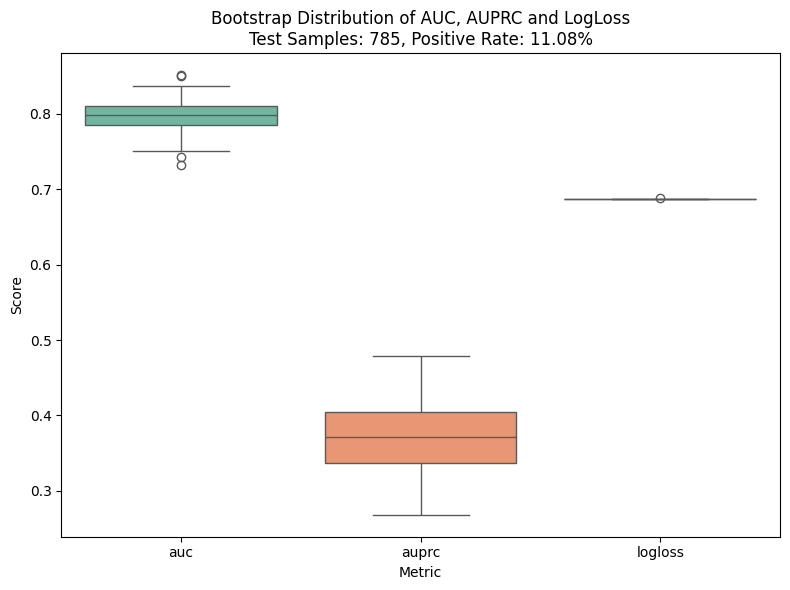

In [39]:
# test the model performance, detailed steps
X_target_test, y_target_test = X_test.copy(), y_test.copy()

# ✅ load the model
final_model_path = '/content/saved_models_xgboost_single/best_xgboost_19_final.model'
model = xgb.Booster()
model.load_model(final_model_path)

# ✅ create DMatrix for testing set
dtest = xgb.DMatrix(X_target_test)

# ✅ make the prediction
test_preds_proba = model.predict(dtest)

# ✅ evaluation metrics
test_auc = roc_auc_score(y_target_test, test_preds_proba)
test_auprc = average_precision_score(y_target_test, test_preds_proba)

# ✅ Bootstrap evaluation
n_bootstrap = 100
aucs, auprcs, loglosses = [], [], []
rng = np.random.default_rng(seed=42)

for _ in range(n_bootstrap):
    indices = rng.choice(len(y_target_test), size=len(y_target_test), replace=True)
    y_true_boot = y_target_test[indices]
    y_pred_boot = test_preds_proba[indices]

    if len(np.unique(y_true_boot)) < 2:
        continue

    aucs.append(roc_auc_score(y_true_boot, y_pred_boot))
    auprcs.append(average_precision_score(y_true_boot, y_pred_boot))
    loglosses.append(log_loss(y_true_boot, y_pred_boot))

auc_ci = np.percentile(aucs, [2.5, 97.5])
auprc_ci = np.percentile(auprcs, [2.5, 97.5])
logloss_ci = np.percentile(loglosses, [2.5, 97.5])

print(f"✅ testing set AUC: {test_auc:.4f} (95% CI: {auc_ci[0]:.4f} - {auc_ci[1]:.4f})")
print(f"✅ testing set AUPRC: {test_auprc:.4f} (95% CI: {auprc_ci[0]:.4f} - {auprc_ci[1]:.4f})")
print(f"✅ testing set LogLoss: {log_loss(y_target_test, test_preds_proba):.4f} (95% CI: {logloss_ci[0]:.4f} - {logloss_ci[1]:.4f})")

# ✅ save bootstrap output
bootstrap_df = pd.DataFrame({
    'auc': aucs,
    'auprc': auprcs,
    'logloss': loglosses
})

!mkdir -p boots_output
csv_path = '/content/boots_output/all-test-19.csv'
bootstrap_df.to_csv(csv_path, index=False)
print(f"📁 bootstrap output saved: {csv_path}")

# ✅ SHAP calculation
shap_values = model.predict(dtest, pred_contribs=True)
shap_df = pd.DataFrame(shap_values, columns=list(X_target_test.columns) + ['bias'])

shap_csv_path = '/content/boots_output/shap_values_all-test-19.csv'
shap_df.to_csv(shap_csv_path, index=False)
print(f"📁 SHAP values saved: {shap_csv_path}")

# ✅ train SHAP calculation
dtrain = xgb.DMatrix(X_target_train)
shap_values_train = model.predict(dtrain, pred_contribs=True)
shap_train_df = pd.DataFrame(shap_values_train, columns=list(X_target_train.columns) + ['bias'])

shap_train_csv_path = '/content/boots_output/shap_values_all-train-19.csv'
shap_train_df.to_csv(shap_train_csv_path, index=False)
print(f"📁 SHAP values for training set saved to: {shap_train_csv_path}")

# ✅ advsese outcome rate
n_samples = len(y_target_test)
positive_rate = y_target_test.sum() / n_samples

# ✅ Boxplot
bootstrap_df_long = bootstrap_df.melt(var_name='Metric', value_name='Score')

plt.figure(figsize=(8, 6))
sns.boxplot(data=bootstrap_df_long, x='Metric', y='Score', palette='Set2')
plt.title(f'Bootstrap Distribution of AUC, AUPRC and LogLoss\n'
          f'Test Samples: {n_samples}, Positive Rate: {positive_rate:.2%}')
plt.ylabel('Score')
plt.xlabel('Metric')
plt.tight_layout()
plt.show()

# Cluster

In [40]:
!mkdir model_19

In [41]:
!mv /content/saved_models_xgboost_single/best_xgboost_19_final.model /content/model_19/best_xgboost_19_final.model

In [42]:
!rm -r /content/saved_models_xgboost_single

In [44]:
model_path = '/content/model_19/best_xgboost_19_final.model'
hospital_id = 19  # updatable

run_shap_umap_hdbscan_analysis(7, model_path, hospital_id)

calcualte training set SHAP values...
training HDBSCAN clustering...
Internal clustering metrics (non-noise samples)：Silhouette: 0.502, DB: 0.715, CH: 1980.071
Computing SHAP values for validation set and mapping clusters...
✅ SHAP + HDBSCAN completed. Results saved to: /content/cluster_19/19_7


# test-all-cluster-performance

In [45]:
evaluate_all_cluster_combinations(
    cluster_csv_path='/content/cluster_19/19_7/sample_cluster_assignments_combined.csv',
    X_target_test=X_target_test.copy(),
    y_target_test=y_target_test,
    model_path='/content/model_19/best_xgboost_19_final.model',
    clusters_to_include=[-1,0,1,2,3,4,5],
    min_comb_size=1,
    max_comb_size=1,
    n_bootstrap=1000,
    output_dir='/content/cluster_combination-19',
    random_seed=42
)

  0%|          | 0/7 [00:00<?, ?it/s]

missing cluster_id size: 0
 Cluser  [-1]：sample size 324, Positive Rate: 8.95%
🎯 test set AUC: 0.6511
🎯 test set AUPRC: 0.1377
🎯 test set LogLoss: 0.6868
✅ test set AUC: 0.6511 (95% CI: 0.5537 - 0.7479)
✅ test set AUPRC: 0.1377 (95% CI: 0.0866 - 0.2311)
✅ test set LogLoss: 0.6868 (95% CI: 0.6861 - 0.6875)


 14%|█▍        | 1/7 [00:03<00:23,  3.95s/it]

missing cluster_id size: 0
 Cluser  [0]：sample size 115, Positive Rate: 38.26%
🎯 test set AUC: 0.6877
🎯 test set AUPRC: 0.5589
🎯 test set LogLoss: 0.6937
✅ test set AUC: 0.6877 (95% CI: 0.5857 - 0.7836)
✅ test set AUPRC: 0.5589 (95% CI: 0.4185 - 0.6973)
✅ test set LogLoss: 0.6937 (95% CI: 0.6926 - 0.6948)


 29%|██▊       | 2/7 [00:07<00:19,  3.87s/it]

...

missing cluster_id size: 0
 Cluser  [2]：sample size 104, Positive Rate: 9.62%
🎯 test set AUC: 0.5000
🎯 test set AUPRC: 0.0962
🎯 test set LogLoss: 0.6915
✅ test set AUC: 0.5000 (95% CI: 0.5000 - 0.5000)
✅ test set AUPRC: 0.0962 (95% CI: 0.0385 - 0.1538)
✅ test set LogLoss: 0.6915 (95% CI: 0.6913 - 0.6917)


 57%|█████▋    | 4/7 [00:16<00:12,  4.04s/it]

missing cluster_id size: 0
 Cluser  [3]：sample size 28, Positive Rate: 0.00%
⚠️ this cluster only include one lable (label=0), skip evalution
missing cluster_id size: 0
 Cluser  [4]：sample size 52, Positive Rate: 1.92%
🎯 test set AUC: 0.4216
🎯 test set AUPRC: 0.0192
🎯 test set LogLoss: 0.6828
✅ test set AUC: 0.4216 (95% CI: 0.3725 - 0.4706)
✅ test set AUPRC: 0.0192 (95% CI: 0.0192 - 0.0769)
✅ test set LogLoss: 0.6828 (95% CI: 0.6828 - 0.6841)


100%|██████████| 7/7 [00:18<00:00,  2.69s/it]

missing cluster_id size: 0
 Cluser  [5]：sample size 124, Positive Rate: 0.00%
⚠️ this cluster only include one lable (label=0), skip evalution
✅ done and saved to /content/cluster_combination-19


# retraining cluster

In [46]:
y_train = pd.Series(y_train, index=X_train.index)
y_target_test = pd.Series(y_target_test, index=X_test.index)

In [49]:
retrain_and_evaluate_all_cluster_combinations(
    cluster_csv_path='/content/cluster_19/19_7/sample_cluster_assignments_combined.csv',
    X_train=X_train,
    y_train=y_train,
    X_test=X_target_test,
    y_test=y_target_test,
    clusters_to_include=[-1, 0, 1, 2, 3,4,5],
    min_comb_size=1,
    max_comb_size=1,
    n_bootstrap=1000,
    output_dir='/content/cluster_combination_retrain_19',
    random_seed=42
)

Cluster combinations:   0%|          | 0/7 [00:00<?, ?it/s]


🚀 Cluster reyraining: -1
combination (-1,) original keep_ids size: 1321
 X.index shared sie: 1321
combination (-1,) original keep_ids size: 324
 X.index shared sie: 324
【XGBOOST】start training - 2026-01-12 18:44:41
✅ model output path: saved_models_xgboost_single/best_xgboost_19_cluster_-1.model
🔧 done parameter selection | best max_depth=6, learning_rate=0.01

🏗️ training xgboost...
[0]	train-logloss:0.68634	train-aucpr:0.45179	eval-logloss:0.68779	eval-aucpr:0.12298
[20]	train-logloss:0.57446	train-aucpr:0.98548	eval-logloss:0.59614	eval-aucpr:0.20149
[30]	train-logloss:0.53086	train-aucpr:0.99006	eval-logloss:0.56012	eval-aucpr:0.24685
✅ completed training | time taken: 0.2s

📊 model evaluation...



Bootstrap evaluation: 100%|██████████| 1000/1000 [00:04<00:00, 225.01it/s]



🎯 final output:
AUROC: 0.8066 (95% CI: 0.7279 - 0.8735)
AUPRC: 0.2597 (95% CI: 0.1625 - 0.4279)
Accuracy: 0.8943

🔁 combine train + val for final training...
✅ trained model saved to: saved_models_xgboost_single/best_xgboost_19_cluster_-1_final.model
AUC: 0.9059 (95% CI: 0.8692-0.9374), p=0.0000
AUPRC: 0.5134 (95% CI: 0.4097-0.6126), p=0.0000
LogLoss: 0.6872 (95% CI: 0.6869-0.6874), p=0.0000
AUC: 0.6152 (95% CI: 0.5013-0.7269), p=0.0240
AUPRC: 0.1650 (95% CI: 0.0929-0.3104), p=0.0210
LogLoss: 0.6888 (95% CI: 0.6881-0.6895), p=0.0000


Cluster combinations: 100%|██████████| 7/7 [01:13<00:00, 10.50s/it]


🚀 Cluster reyraining: 0
combination (0,) original keep_ids size: 402
 X.index shared sie: 402
combination (0,) original keep_ids size: 115
 X.index shared sie: 115
❌ Cluster 0 failed: sample size too small

🚀 Cluster reyraining: 1
combination (1,) original keep_ids size: 128
 X.index shared sie: 128
combination (1,) original keep_ids size: 38
 X.index shared sie: 38
❌ Cluster 1 failed: sample size too small

🚀 Cluster reyraining: 2
combination (2,) original keep_ids size: 439
 X.index shared sie: 439
combination (2,) original keep_ids size: 104
 X.index shared sie: 104
❌ Cluster 2 failed: sample size too small

🚀 Cluster reyraining: 3
combination (3,) original keep_ids size: 95
 X.index shared sie: 95
combination (3,) original keep_ids size: 28
 X.index shared sie: 28
❌ Cluster 3 failed: sample size too small

🚀 Cluster reyraining: 4
combination (4,) original keep_ids size: 232
 X.index shared sie: 232
combination (4,) original keep_ids size: 52
 X.index shared sie: 52
❌ Cluster 4 fai

In [50]:
!zip -r WiDS-19.zip /content/* -x /content/training_v2.csv

  adding: content/boots_output/ (stored 0%)
  adding: content/boots_output/shap_values_all-train-19.csv (deflated 80%)
  adding: content/boots_output/all-test-19.csv (deflated 53%)
  adding: content/boots_output/shap_values_all-test-19.csv (deflated 79%)
  adding: content/cluster_19/ (stored 0%)
  adding: content/cluster_19/19_7/ (stored 0%)
  adding: content/cluster_19/19_7/sample_cluster_assignments_combined.csv (deflated 76%)
  adding: content/cluster_combination-19/ (stored 0%)
  adding: content/cluster_combination-19/cluster_2_results_shap.png (deflated 7%)
  adding: content/cluster_combination-19/cluster_-1_results_shap.csv (deflated 78%)
  adding: content/cluster_combination-19/cluster_1_results.csv (deflated 97%)
  adding: content/cluster_combination-19/cluster_4_results_shap.csv (deflated 82%)
  adding: content/cluster_combination-19/cluster_1_results_shap.png (deflated 9%)
  adding: content/cluster_combination-19/cluster_2_results.csv (deflated 96%)
  adding: content/cluster_